<a href="https://colab.research.google.com/github/Anukram01/IPL--DATA-ANALYTICS-/blob/main/IPL_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. Loading IPL Matches Dataset ---
Data Loaded Successfully! Total Matches: 577

Columns in Dataset:
 ['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

--- Top 8 Most Successful IPL Teams ---
winner
Mumbai Indians                 80
Chennai Super Kings            79
Royal Challengers Bengaluru    70
Kolkata Knight Riders          68
Punjab Kings                   63
Rajasthan Royals               63
Sunrisers Hyderabad            63
Delhi Capitals                 56
Name: count, dtype: int64

Percentage of matches where Toss Winner won the Match: 50.70%
Wins when deciding to Field: 313
Wins when deciding to Bat: 261

--- Top 10 Player of the Match Recipients ---
player_of_match
CH Gayle          17
YK Pathan         16
AB de Villiers    15
DA Warner         14
RG Sharma         13
SK Raina          13
MEK Hussey        12


/tmp/ipykernel_1951/509455573.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_winners.values, y=top_winners.index, palette="viridis")


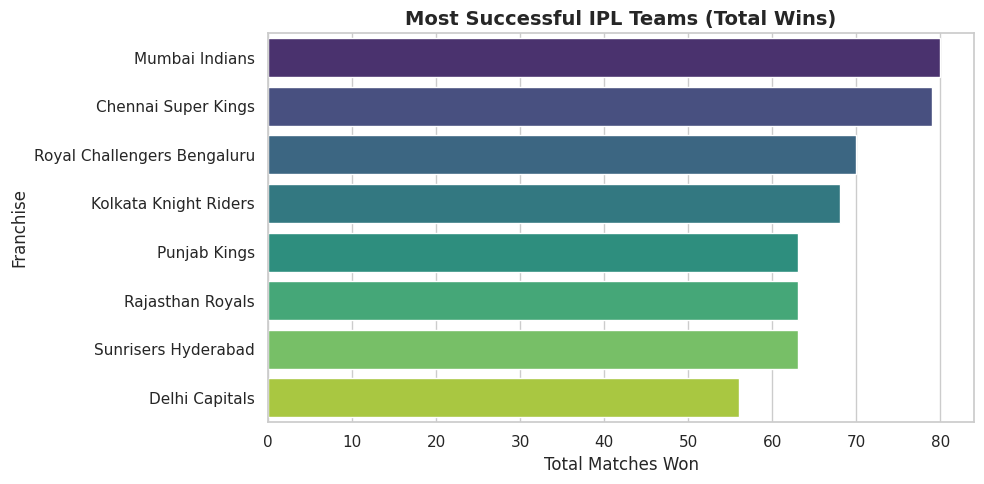

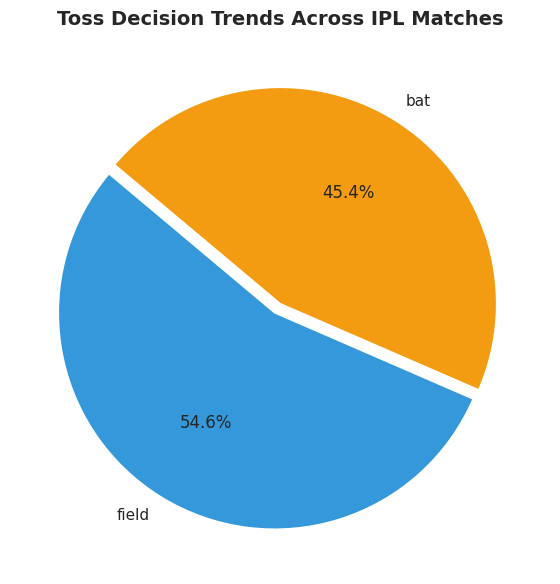

/tmp/ipykernel_1951/509455573.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mom.index, y=top_mom.values, palette="magma")


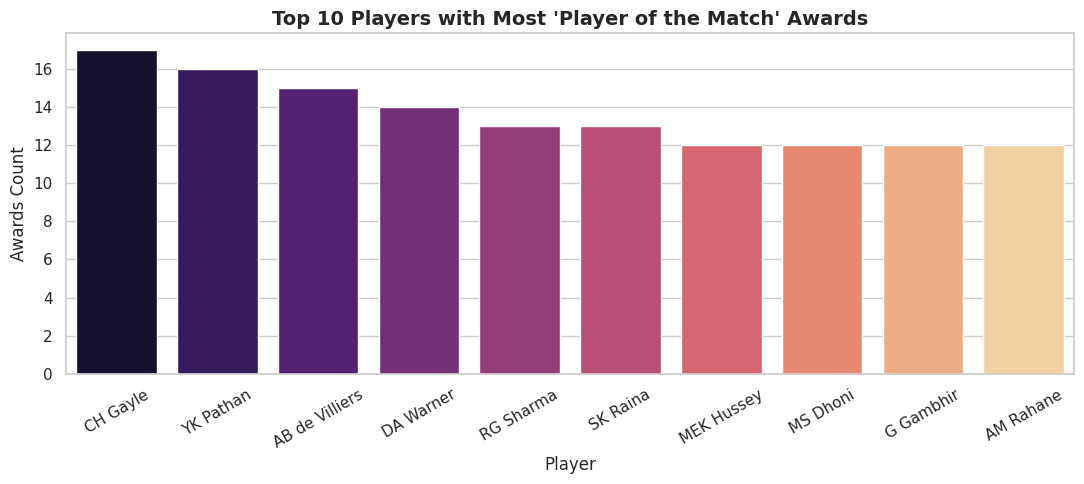


All visualizations created and saved as PNG images successfully!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("--- 1. Loading IPL Matches Dataset ---")
# Direct raw GitHub URL for verified IPL Matches dataset
DATA_URL = "https://raw.githubusercontent.com/12345k/IPL-Dataset/master/IPL/data.csv"
df = pd.read_csv(DATA_URL)

print(f"Data Loaded Successfully! Total Matches: {len(df)}")
print("\nColumns in Dataset:\n", list(df.columns))

# --- 2. Data Cleaning & Standardization ---
# Normalize team names (Handling franchise name changes/variations)
team_mappings = {
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}
df["winner"] = df["winner"].replace(team_mappings)
df["team1"] = df["team1"].replace(team_mappings)
df["team2"] = df["team2"].replace(team_mappings)
df["toss_winner"] = df["toss_winner"].replace(team_mappings)

# --- 3. Key Analytical Insights ---

# A. Most Successful Teams (Most Wins)
top_winners = df["winner"].value_counts().head(8)
print("\n--- Top 8 Most Successful IPL Teams ---")
print(top_winners)

# B. Toss Advantage Analysis (Does winning toss lead to match win?)
df["toss_match_win"] = (df["toss_winner"] == df["winner"])
toss_win_pct = (df["toss_match_win"].sum() / len(df.dropna(subset=["winner"]))) * 100
print(f"\nPercentage of matches where Toss Winner won the Match: {toss_win_pct:.2f}%")

# C. Toss Decision Impact: Bat first vs Field first win rate
field_first_wins = df[df["toss_decision"] == "field"]["winner"].count()
bat_first_wins = df[df["toss_decision"] == "bat"]["winner"].count()
print(f"Wins when deciding to Field: {field_first_wins}")
print(f"Wins when deciding to Bat: {bat_first_wins}")

# D. Top 10 'Player of the Match' Award Winners
top_mom = df["player_of_match"].value_counts().head(10)
print("\n--- Top 10 Player of the Match Recipients ---")
print(top_mom)

# --- 4. Visualizations Generation ---

# Plot 1: Top IPL Teams by Wins
plt.figure(figsize=(10, 5))
sns.barplot(x=top_winners.values, y=top_winners.index, palette="viridis")
plt.title("Most Successful IPL Teams (Total Wins)", fontsize=14, fontweight="bold")
plt.xlabel("Total Matches Won")
plt.ylabel("Franchise")
plt.tight_layout()
plt.savefig("top_teams_wins.png")
plt.show()

# Plot 2: Toss Decision Distribution (Batting vs Fielding)
plt.figure(figsize=(6, 6))
toss_decision_counts = df["toss_decision"].value_counts()
plt.pie(
    toss_decision_counts.values,
    labels=toss_decision_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#3498db", "#f39c12"],
    explode=(0.05, 0)
)
plt.title("Toss Decision Trends Across IPL Matches", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("toss_decision_share.png")
plt.show()

# Plot 3: Top 10 Most Impactful Players (Player of the Match)
plt.figure(figsize=(11, 5))
sns.barplot(x=top_mom.index, y=top_mom.values, palette="magma")
plt.title("Top 10 Players with Most 'Player of the Match' Awards", fontsize=14, fontweight="bold")
plt.xlabel("Player")
plt.ylabel("Awards Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("top_players_mom.png")
plt.show()

print("\nAll visualizations created and saved as PNG images successfully!")

In [4]:
import pandas as pd
import numpy as np

print("--- Advanced Venue & Margin Analytics ---")

# 1. Venue-wise Toss Advantage (Kahan toss jeetna sabse zyada faydemand raha?)
venue_stats = df.groupby('venue').agg(
    total_matches=('id', 'count'),
    toss_and_match_wins=('toss_match_win', 'sum')
).reset_index()

# Filter venues with at least 15 matches for statistical significance
venue_stats = venue_stats[venue_stats['total_matches'] >= 15]
venue_stats['toss_win_pct'] = (venue_stats['toss_and_match_wins'] / venue_stats['total_matches']) * 100
top_venues = venue_stats.sort_values(by='toss_win_pct', ascending=False).head(10)

print("\n--- Top Venues by Toss-Winner Win % (Min 15 matches) ---")
print(top_venues[['venue', 'total_matches', 'toss_win_pct']].to_string(index=False))

# 2. Defending vs Chasing Dominance Analysis
df['win_by_runs'] = pd.to_numeric(df['win_by_runs'], errors='coerce').fillna(0)
df['win_by_wickets'] = pd.to_numeric(df['win_by_wickets'], errors='coerce').fillna(0)

defended_matches = df[df['win_by_runs'] > 0]
chased_matches = df[df['win_by_wickets'] > 0]

print("\n--- Match Outcome Distribution ---")
print(f"Total Matches Won by Defending (Runs): {len(defended_matches)}")
print(f"Total Matches Won by Chasing (Wickets): {len(chased_matches)}")
print(f"Average Win Margin when Defending: {defended_matches['win_by_runs'].mean():.1f} runs")
print(f"Average Win Margin when Chasing: {chased_matches['win_by_wickets'].mean():.1f} wickets")

# 3. Most Dominant Franchise Wins (Wins by >50 runs or by 8+ wickets)
blowout_wins = df[(df['win_by_runs'] >= 50) | (df['win_by_wickets'] >= 8)]
top_blowouts = blowout_wins['winner'].value_counts().head(5)

print("\n--- Most Dominant Victories by Franchise (>50 runs or 8+ wkts) ---")
print(top_blowouts.to_string())

--- Advanced Venue & Margin Analytics ---

--- Top Venues by Toss-Winner Win % (Min 15 matches) ---
                                     venue  total_matches  toss_win_pct
                                 Kingsmead             15     60.000000
                              Eden Gardens             54     55.555556
                Dr DY Patil Sports Academy             17     52.941176
                Subrata Roy Sahara Stadium             17     52.941176
           MA Chidambaram Stadium, Chepauk             48     52.083333
                     M Chinnaswamy Stadium             58     51.724138
                          Feroz Shah Kotla             53     49.056604
                          Wankhede Stadium             49     48.979592
Punjab Cricket Association Stadium, Mohali             35     45.714286
                    Sawai Mansingh Stadium             33     45.454545

--- Match Outcome Distribution ---
Total Matches Won by Defending (Runs): 261
Total Matches Won by Chasing 